In [1]:
import torch
import time
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv('proportional_sample_20pct_size_10pct_attack.csv')

**Preprocessing**

In [ ]:
def preprocess(df):
    """
    Engineer features and preprocess data
    """

    df["Weight"] = df["Total Fwd Packet"] * df["Total Bwd packets"]

    categorical_columns = ["Src IP", 'Dst IP', "Src Port", "Dst Port", "Protocol"]

    for col in categorical_columns:
        df[col] = df[col].astype('category')

    
    for col in ['Src IP', 'Dst IP', 'Src Port', 'Dst Port']:
         df[col + '_freq'] = df[col].map(df[col].value_counts())

    df = pd.get_dummies(df, columns=['Protocol'], prefix='Proto')

    df['Timestamp'] = pd.to_datetime(df['Timestamp'],  format='%d/%m/%Y %I:%M:%S %p')

    attacks_to_remove = [
    "spoofing_ARP Spoofing",
    "spoofing_DNS Spoofing",
    "sqlinjection",
    "XSS",
    "Uploading_Attack"  ]

    df = df[~df["Attack_Type"].isin(attacks_to_remove)]
    

    df['Flow_Duration'] = df['Flow Duration'] / 1_000_000


    df['Flow_Duration'] = df['Flow_Duration'].replace(0, 1e-6)
        
    # === DDoS Detection Features ===
    
    # 2. Flow asymmetry indicators
    df['Fwd_Bwd_Packet_Ratio'] = df['Total Fwd Packet'] / (df['Total Bwd packets'] + 1)
    df['Fwd_Bwd_Bytes_Ratio'] = df['Total Length of Fwd Packet'] / (df['Total Length of Bwd Packet'] + 1)
    
    # 3. Packet size anomalies
    df['Avg_Fwd_Packet_Size'] = df['Total Length of Fwd Packet'] / (df['Total Fwd Packet'] + 1)
    df['Packet_Size_Variance_Ratio'] = df['Packet Length Variance'] / (df['Flow Bytes/s'] + 1)
    
    # === Protocol-Specific Features ===
    
    # 4. ICMP Flood Detection 
    df['ICMP_Flood_Score'] = (
        df['Proto_17'] * 
        df['Fwd Packets/s'] * 
        (df['Total Fwd Packet'] > df['Total Fwd Packet'].quantile(0.8)).astype(int)
    )
    
    # 5. TCP-based DDoS indicators 
    df['TCP_Flood_Score'] = (
        df['Proto_6'] * 
        df['Fwd Packets/s'] * 
        (df['SYN Flag Count'] + df['RST Flag Count'] + df['FIN Flag Count'])
    )
    
    # 6. HTTP Flood Detection (common web ports + high packet rate)
    http_port_mask = (
        (df['Dst Port'] == 80) | 
        (df['Dst Port'] == 443) | 
        (df['Dst Port'] == 8080) | 
        (df['Dst Port'] == 8443)
    )
    df['HTTP_Flood_Score'] = (
        http_port_mask.astype(int) * 
        df['Fwd Packets/s'] * 
        (df['PSH Flag Count'] + df['Fwd PSH Flags'] + df['Bwd PSH Flags'])
    )
    
    # === Vulnerability Scan Detection ===
    
    # 7. Port scanning indicators using existing frequency features
    df['Port_Scan_Score'] = (
        df['Dst Port_freq'] *  # High destination port diversity
        df['Src IP_freq'] *    # From same source IP
        (df['Total Fwd Packet'] < df['Total Fwd Packet'].quantile(0.5)).astype(int)  # Small packets
    )
    
    # 8. Network scanning behavior
    df['Network_Scan_Score'] = (
        df['Dst IP_freq'] *    # High destination IP diversity
        df['Src IP_freq'] *    # From same source
        (df['SYN Flag Count'] > 0).astype(int) *  # TCP SYN packets
        (df['Total Length of Bwd Packet'] == 0).astype(int)  # No response packets
    )
    
    # === Advanced DDoS Features ===
    
    # 9. Inter-arrival time anomalies (consistent timing in DDoS)
    df['IAT_Consistency'] = np.where(
        df['Fwd IAT Std'] > 0,
        df['Fwd IAT Mean'] / df['Fwd IAT Std'],
        0
    )
    
    # === Combined Attack Indicators ===
    
    # 13. Multi-feature DDoS score
    df['DDoS_Combined_Score'] = (
        df['Fwd Packets/s'] * 0.3 +
        df['ICMP_Flood_Score'] * 0.2 +
        df['TCP_Flood_Score'] * 0.2 +
        df['HTTP_Flood_Score'] * 0.2 +
        df['IAT_Consistency'] * 0.1
    )
    
    # 14. Vulnerability scan combined score
    df['Scan_Combined_Score'] = (
        df['Port_Scan_Score'] * 0.4 +
        df['Network_Scan_Score'] * 0.4 +
        (df['Dst Port_freq'] * df['Dst IP_freq']) * 0.2
    )
    
    # === Statistical Anomaly Features ===
    
    # 16. Flag usage anomalies
    df['Flag_Usage_Score'] = (
        df['SYN Flag Count'] + 
        df['RST Flag Count'] + 
        df['FIN Flag Count'] + 
        df['PSH Flag Count'] + 
        df['URG Flag Count']
    ) / (df['Total Fwd Packet'] + 1)
    
    # 17. Subflow anomalies
    df['Subflow_Anomaly'] = np.abs(
        df['Subflow Fwd Bytes'] - df['Subflow Bwd Bytes']
    ) / (df['Flow Bytes/s'] + 1)
    
    # === Target Attack Specific Features ===
    

    attack_indicators = {}
    
    # DDoS-HTTP Flood specific
    attack_indicators['DDoS_HTTP_Indicator'] = (
        df['HTTP_Flood_Score'] * 
        (df['Proto_6'] == 1).astype(int) *  # TCP protocol
        (df['Fwd Packets/s'] > df['Fwd Packets/s'].quantile(0.9)).astype(int)
    )
    
    # DDoS-ICMP Flood specific  
    attack_indicators['DDoS_ICMP_Indicator'] = (
        df['ICMP_Flood_Score'] *
        (df['Bwd Packet Length Min'] == 0).astype(int) *  # Often no response
        (df['Fwd Packets/s'] > df['Fwd Packets/s'].quantile(0.8)).astype(int)
    )
    
    # DDoS-ICMP Fragmentation specific
    attack_indicators['DDoS_ICMP_Frag_Indicator'] = (
        df['Proto_17'] *  # ICMP
        (df['Packet Length Variance'] > df['Packet Length Variance'].quantile(0.7)).astype(int) *
        df['Fwd Packets/s']
    )
    
    # Vulnerability Scan specific
    attack_indicators['VulnScan_Indicator'] = (
        df['Scan_Combined_Score'] *
        (df['Active Min'] > 0).astype(int) *  # Active probing
        (df['Total Length of Bwd Packet'] < df['Total Length of Fwd Packet']).astype(int)
    )
    

    for indicator_name, indicator_values in attack_indicators.items():
        df[indicator_name] = indicator_values


    columns_to_drop = ["Flow IAT Std",
                   "Bwd Segment Size Avg",
                   "Subflow Fwd Packets",
    'Flow Duration',
    'Subflow Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Flow Packets/s',
    'Flow IAT Min',
    'Flow IAT Max',
    'Bwd IAT Max',
    'Bwd IAT Min',
    'Fwd Header Length',
    'ACK Flag Count',
    'Packet Length Std',
    "Fwd IAT Max",
    "Idle Max",
    "Idle Min",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Max",
    'Average Packet Size',
    'Fwd Segment Size Avg',
    'Fwd IAT Max',
    'Bwd Header Length',
    'Packet Length Mean',
    'CWR Flag Count',
    'Average Packet Size',
    "Flow IAT Mean",
    "Active Max",
    "Bwd Bytes/Bulk Avg",
    'Fwd IAT Mean',
    'Active Mean',
    'Active Std',
    "Fwd Act Data Pkts",
    "Flow_Duration",
    "ICMP_Flood_Score",
    "HTTP_Flood_Score",
    "Port_Scan_Score",
    "IAT_Consistency" ,
    "DDoS_Combined_Score"
]

    df = df.drop(columns=columns_to_drop)
    df = df.drop(columns="Label")


    null_columns = df.isnull().sum()
    null_columns = null_columns[null_columns > 0]
    df = df.dropna()
    df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
        
    return df

In [5]:
df = preprocess(df)

**Combine Attack Types for Anomaly Detection Preperation**

In [6]:
def create_anomaly_label(row):
    if row['Attack_Type'] == 'Benign&Bruteforce_benign':
        return 'Normal'
    else:
        return 'Attack'


In [7]:
df['Anomaly_Label'] = df.apply(create_anomaly_label, axis=1)

***Begin preparation for the model***

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation=nn.ReLU(), dropout_rate=0.0,
                 sequence_length=1, num_layers=1, bidirectional=False):
        super(LSTMAutoencoder, self).__init__()

        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.bottleneck_dim = hidden_dims[-1]
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.directions = 2 if bidirectional else 1
        self.activation = activation

        # Encoder 
        self.encoder_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.encoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=h_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = h_dim * self.directions

        # Decoder 
        self.decoder_layers = nn.ModuleList()
        reversed_dims = list(reversed(hidden_dims))
        prev_dim = reversed_dims[0] * self.directions  # bottleneck dimension

        # Create decoder layers
        for i in range(len(reversed_dims) - 1):
            next_dim = reversed_dims[i+1]
            self.decoder_layers.append(nn.LSTM(
                input_size=prev_dim,
                hidden_size=next_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=bidirectional
            ))
            prev_dim = next_dim * self.directions

        # Final output layer
        self.output_layer = nn.Linear(hidden_dims[0] * self.directions, input_dim)

        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):

        original_shape = x.shape
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  # [batch_size, 1, input_dim]

        batch_size = x.size(0)
        seq_len = x.size(1)

        # Encode
        current_input = x
        for i, encoder in enumerate(self.encoder_layers):
            outputs, (hidden, cell) = encoder(current_input)
            current_input = outputs


            if self.activation is not None:
                current_input = self.activation(current_input)

            if self.dropout is not None and i < len(self.encoder_layers) - 1:
                current_input = self.dropout(current_input)


        encoded = outputs[:, -1, :]


        decoder_input = encoded.unsqueeze(1).repeat(1, seq_len, 1)

        # Decode
        current_input = decoder_input
        for i, decoder in enumerate(self.decoder_layers):
            outputs, _ = decoder(current_input)
            current_input = outputs

      
            if self.activation is not None and i < len(self.decoder_layers) - 1:
                current_input = self.activation(current_input)

         
            if self.dropout is not None and i < len(self.decoder_layers) - 1:
                current_input = self.dropout(current_input)

  
        reconstructed = self.output_layer(current_input)

        if len(original_shape) == 2:
            reconstructed = reconstructed.squeeze(1)

        return reconstructed, encoded

**Seperate training and test data**

In [9]:
X = df.select_dtypes(include=['number', 'bool'])
X_datetime = df.select_dtypes(include=['datetime64'])
# Get the Attack_Types column (string column)
attack_types = df['Attack_Type']  # Keep original attack types for stratification
y = df['Anomaly_Label']  # Target variable
y_binary = (y == "Attack").astype(int)  # Attack = 1, Normal = 0

# Create a combined stratification column that includes both binary label and attack types
# This ensures we maintain the distribution of different attack types
df_temp = df.copy()
df_temp['stratify_col'] = df_temp['Attack_Type']  # Already string, no need to convert

# For normal/benign cases, we can group them as one category
# For attacks, we keep the specific attack type
df_temp.loc[df_temp['Anomaly_Label'] == 'Normal', 'stratify_col'] = 'Normal'

print("Original Attack Type Distribution:")
print(df_temp['stratify_col'].value_counts())
print(f"\nOriginal Attack/Normal Distribution:")
print(df_temp['Anomaly_Label'].value_counts())

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert datetime to Unix timestamps (seconds)
for col in X_datetime.columns:
    X_datetime[col] = pd.to_datetime(X_datetime[col]).astype('int64') // 10**9

# Scale numerical and boolean features
scaler_numerical = StandardScaler()
X_scaled_num = scaler_numerical.fit_transform(X)

# Scale datetime features
scaler_datetime = StandardScaler()
X_scaled_datetime = scaler_datetime.fit_transform(X_datetime)

# Combine scaled features into a single NumPy array
X_scaled = np.concatenate([X_scaled_num, X_scaled_datetime], axis=1)
print("Had ", X_scaled.shape[1] ,"features")

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_scaled = pca.fit_transform(X_scaled)


print("Components after reduction: ", pca.n_components_)  # number of components after reduction


# Split full dataset into train/test (70/30) with stratification on attack types
try:
    X_train_full, X_test, y_train_full, y_test, stratify_train, stratify_test = train_test_split(
        X_scaled, y_binary, df_temp['stratify_col'], 
        test_size=0.3, random_state=42, stratify=df_temp['stratify_col']
    )
    
    # Create arrays to track original indices
    original_indices = np.arange(len(X_scaled))
    train_indices, test_indices = train_test_split(
        original_indices, test_size=0.3, random_state=42, stratify=df_temp['stratify_col']
    )

    print("\n=== TRAIN SET DISTRIBUTION ===")
    train_stratify_counts = pd.Series(stratify_train).value_counts()
    print("Attack Type Distribution in Training Set:")
    print(train_stratify_counts)
    print(f"Normal vs Attack in Training Set:")
    print(pd.Series(y_train_full).value_counts())
    
    print("\n=== TEST SET DISTRIBUTION ===")
    test_stratify_counts = pd.Series(stratify_test).value_counts()
    print("Attack Type Distribution in Test Set:")
    print(test_stratify_counts)
    print(f"Normal vs Attack in Test Set:")
    print(pd.Series(y_test).value_counts())
    
except ValueError as e:
    print(f"Stratification failed: {e}")
    print("Some attack types might have too few samples. Using alternative approach...")
    
    # Alternative approach: Manual stratified sampling for rare classes
    from collections import defaultdict
    
    # Group indices by attack type
    attack_type_indices = defaultdict(list)
    for idx, attack_type in enumerate(df_temp['stratify_col']):
        attack_type_indices[attack_type].append(idx)
    
    train_indices = []
    test_indices = []
    
    for attack_type, indices in attack_type_indices.items():
        if len(indices) == 1:
            # If only one sample, put it in training
            train_indices.extend(indices)
        else:
            # Split proportionally
            n_test = max(1, int(len(indices) * 0.3))
            np.random.shuffle(indices)
            test_indices.extend(indices[:n_test])
            train_indices.extend(indices[n_test:])
    
    # Create train/test splits
    X_train_full = X_scaled[train_indices]
    X_test = X_scaled[test_indices]
    y_train_full = y_binary.iloc[train_indices].values
    y_test = y_binary.iloc[test_indices].values
    stratify_train = df_temp['stratify_col'].iloc[train_indices].values
    stratify_test = df_temp['stratify_col'].iloc[test_indices].values
    


Original Attack Type Distribution:
stratify_col
Normal                          398198
DoS_DoS SYN Flood               330518
DoS_DoS-UDP_Flood               105701
DDoS_DDoS ACK Fragmentation      49710
DoS_DoS-HTTP_Flood               24931
DDoS_DDoS-HTTP Flood             10248
VulnerabilityScan                 8968
DDoS_DDoS-ICMP_Fragmentation      6503
DDoS_DDoS ICMP Flood              4094
Mirai                             3542
Benign&Bruteforce_BruteForce        73
Name: count, dtype: int64

Original Attack/Normal Distribution:
Anomaly_Label
Attack    544288
Normal    398198
Name: count, dtype: int64
Using device: cuda
Had  66 features
Components after reduction:  35

=== TRAIN SET DISTRIBUTION ===
Attack Type Distribution in Training Set:
stratify_col
Normal                          278738
DoS_DoS SYN Flood               231362
DoS_DoS-UDP_Flood                73991
DDoS_DDoS ACK Fragmentation      34797
DoS_DoS-HTTP_Flood               17452
DDoS_DDoS-HTTP Flood              7

In [10]:
print("\n=== TRAIN SET DISTRIBUTION (Manual Split) ===")
print("Attack Type Distribution in Training Set:")
print(pd.Series(stratify_train).value_counts())
print(f"Normal vs Attack in Training Set:")
print(pd.Series(y_train_full).value_counts())

print("\n=== TEST SET DISTRIBUTION (Manual Split) ===")
print("Attack Type Distribution in Test Set:")
print(pd.Series(stratify_test).value_counts())
print(f"Normal vs Attack in Test Set:")
print(pd.Series(y_test).value_counts())


=== TRAIN SET DISTRIBUTION (Manual Split) ===
Attack Type Distribution in Training Set:
stratify_col
Normal                          278738
DoS_DoS SYN Flood               231362
DoS_DoS-UDP_Flood                73991
DDoS_DDoS ACK Fragmentation      34797
DoS_DoS-HTTP_Flood               17452
DDoS_DDoS-HTTP Flood              7174
VulnerabilityScan                 6278
DDoS_DDoS-ICMP_Fragmentation      4552
DDoS_DDoS ICMP Flood              2866
Mirai                             2479
Benign&Bruteforce_BruteForce        51
Name: count, dtype: int64
Normal vs Attack in Training Set:
Anomaly_Label
1    381002
0    278738
Name: count, dtype: int64

=== TEST SET DISTRIBUTION (Manual Split) ===
Attack Type Distribution in Test Set:
stratify_col
Normal                          119460
DoS_DoS SYN Flood                99156
DoS_DoS-UDP_Flood                31710
DDoS_DDoS ACK Fragmentation      14913
DoS_DoS-HTTP_Flood                7479
DDoS_DDoS-HTTP Flood              3074
VulnerabilityS

**ONE CLASS SVM**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')


class OneClassSVMDetector:
    def __init__(self, nu=0.1, kernel='rbf', gamma='scale'):
        """
        Initialize One-Class SVM detector
        
        Parameters:
        - nu: Upper bound on the fraction of training errors and lower bound of the fraction of support vectors
        - kernel: Kernel type ('linear', 'poly', 'rbf', 'sigmoid')
        - gamma: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
        """
        self.nu = nu
        self.kernel = kernel
        self.gamma = gamma
        self.model = None
        self.is_fitted = False
        
    def fit(self, X, y=None):
        """
        Fit One-Class SVM on normal data only
        
        Parameters:
        - X: Training features
        - y: Training labels (optional, used to filter normal samples)
        """

        if y is not None:
            normal_mask = (y == 0)
            X_normal = X[normal_mask]
            print(f"Training on {len(X_normal)} normal samples out of {len(X)} total samples")
        else:
            X_normal = X
            print(f"Training on all {len(X)} samples (assuming all are normal)")
        
      
        self.model = OneClassSVM(
            nu=self.nu,
            kernel=self.kernel,
            gamma=self.gamma
        )
        
        self.model.fit(X_normal)
        self.is_fitted = True
        
        return self
    
    def predict(self, X):
        """
        Predict anomalies using One-Class SVM
        Returns: 1 for normal, -1 for anomaly (as per sklearn convention)
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before making predictions")
        
        return self.model.predict(X)
    
    def predict_binary(self, X):
        """
        Predict anomalies and convert to binary format
        Returns: 0 for normal, 1 for anomaly
        """
        predictions = self.predict(X)
        
        return (predictions == -1).astype(int)
    
    def decision_function(self, X):
        """
        Get decision scores (distance from separating hyperplane)
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before computing decision function")
        
        return self.model.decision_function(X)

def tune_oneclass_svm_fixed(X_train, y_train, sample_size=15000):
    """
    Tune One-Class SVM hyperparameters using a sample for speed
    """
    print("Tuning One-Class SVM hyperparameters...")
    
    
    normal_mask = (y_train == 0)
    X_normal = X_train[normal_mask]
    
    
    if len(X_normal) > sample_size:
        print(f"Using sample of {sample_size} normal samples for tuning...")
        np.random.seed(42)
        sample_indices = np.random.choice(len(X_normal), size=sample_size, replace=False)
        X_normal_sample = X_normal[sample_indices]
    else:
        X_normal_sample = X_normal
    
    
    param_combinations = [
        {'nu': 0.05, 'kernel': 'linear'},
        {'nu': 0.1, 'kernel': 'linear'},
        {'nu': 0.2, 'kernel': 'linear'},
        {'nu': 0.05, 'kernel': 'rbf', 'gamma': 'scale'},
        {'nu': 0.1, 'kernel': 'rbf', 'gamma': 'scale'},
        {'nu': 0.2, 'kernel': 'rbf', 'gamma': 'scale'},
        {'nu': 0.1, 'kernel': 'rbf', 'gamma': 0.01},
        {'nu': 0.1, 'kernel': 'rbf', 'gamma': 0.1}
    ]
    
    best_score = -1
    best_params = None
    print("Testing parameter combinations...")
    
    for i, params in enumerate(param_combinations):
        try:
          
            model = OneClassSVM( **params)
            model.fit(X_normal_sample)
            
       
            train_pred = model.predict(X_train)
            train_pred_binary = (train_pred == -1).astype(int)
            
      
            score = f1_score(y_train, train_pred_binary, zero_division=0)
            
            print(f"  {params}: F1 = {score:.4f}")
            
            if score > best_score:
                best_score = score
                best_params = params.copy()
                
        except Exception as e:
            print(f"  {params}: FAILED ({str(e)[:50]}...)")
            continue
    
    if best_params is None:
        print("All parameter combinations failed. Using default parameters.")
        best_params = {'nu': 0.1, 'kernel': 'linear'}
        best_score = 0.0
    
    print(f"\nBest parameters: {best_params}")
    print(f"Best F1 score: {best_score:.4f}")
    
    return best_params

def evaluate_oneclass_svm(model, X_test, y_test, title_suffix=""):
    """
    Comprehensive evaluation of One-Class SVM model
    """

    predictions = model.predict_binary(X_test)
    decision_scores = model.decision_function(X_test)
    

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    

    roc_auc = roc_auc_score(y_test, -decision_scores)  
    
    print(f"\n=== One-Class SVM Evaluation Results {title_suffix} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    

    cm = confusion_matrix(y_test, predictions)
    print(f"\nConfusion Matrix:")
    print(cm)
    

    print(f"\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=['Normal', 'Attack']))
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
    axes[0,0].set_title(f'Confusion Matrix {title_suffix}')
    axes[0,0].set_xlabel('Predicted')
    axes[0,0].set_ylabel('Actual')
    

    axes[0,1].hist(decision_scores[y_test == 0], bins=50, alpha=0.7, label='Normal', color='blue')
    axes[0,1].hist(decision_scores[y_test == 1], bins=50, alpha=0.7, label='Attack', color='red')
    axes[0,1].set_xlabel('Decision Score')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title(f'Decision Score Distribution {title_suffix}')
    axes[0,1].legend()
    

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, -decision_scores)
    axes[1,0].plot(recall_vals, precision_vals)
    axes[1,0].set_xlabel('Recall')
    axes[1,0].set_ylabel('Precision')
    axes[1,0].set_title(f'Precision-Recall Curve {title_suffix}')
    axes[1,0].grid(True)
    
    # ROC Curve
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, -decision_scores)
    axes[1,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    axes[1,1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[1,1].set_xlabel('False Positive Rate')
    axes[1,1].set_ylabel('True Positive Rate')
    axes[1,1].set_title(f'ROC Curve {title_suffix}')
    axes[1,1].legend()
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': predictions,
        'decision_scores': decision_scores
    }

# Fast training function for large datasets
def train_fast_oneclass_svm(X_train, y_train, sample_size=10000):
    """
    Train One-Class SVM on a subset of data for faster training
    """
    # Extract normal samples
    normal_mask = (y_train == 0)
    X_normal = X_train[normal_mask]
    
    print(f"Total normal samples: {len(X_normal)}")
    
    if len(X_normal) > sample_size:
        print(f"Sampling {sample_size} normal samples for faster training...")
        
        np.random.seed(42)
        sample_indices = np.random.choice(len(X_normal), size=sample_size, replace=False)
        X_normal_sample = X_normal[sample_indices]
    else:
        X_normal_sample = X_normal
        
    return X_normal_sample

# Main execution
if __name__ == "__main__":
    print("=== One-Class SVM Anomaly Detection ===")
    print("Dataset size is large - using optimized approach for faster training")
    
    # FAST OPTION 1: Use linear kernel (much faster)
    print("\n1. Training One-Class SVM with LINEAR kernel (fast)...")
    detector_linear = OneClassSVM(nu=0.1, kernel='linear')
    

    normal_mask = (y_train_full == 0)
    X_normal = X_train_full[normal_mask]
    print(f"Training on {len(X_normal)} normal samples...")
    
    import time
    start_time = time.time()
    detector_linear.fit(X_normal)
    linear_train_time = time.time() - start_time
    print(f"Linear kernel training completed in {linear_train_time:.2f} seconds")
    
   
    linear_pred = detector_linear.predict(X_test)
    linear_pred_binary = (linear_pred == -1).astype(int)
    linear_f1 = f1_score(y_test, linear_pred_binary)
    print(f"Linear SVM F1-Score: {linear_f1:.4f}")
    
    # FAST OPTION 2: Sample subset + RBF kernel
    print(f"\n2. Training One-Class SVM with RBF kernel on SUBSET (fast)...")
    X_normal_sample = train_fast_oneclass_svm(X_train_full, y_train_full, sample_size=20000)
    
    detector_rbf_fast = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
    start_time = time.time()
    detector_rbf_fast.fit(X_normal_sample)
    rbf_train_time = time.time() - start_time
    print(f"RBF kernel (subset) training completed in {rbf_train_time:.2f} seconds")
    
    # Evaluate RBF subset model
    rbf_pred = detector_rbf_fast.predict(X_test)
    rbf_pred_binary = (rbf_pred == -1).astype(int)
    rbf_f1 = f1_score(y_test, rbf_pred_binary)
    print(f"RBF SVM (subset) F1-Score: {rbf_f1:.4f}")
    
    print(f"\n=== TRAINING TIME COMPARISON ===")
    print(f"Linear kernel (full data): {linear_train_time:.2f} seconds")
    print(f"RBF kernel (20K samples): {rbf_train_time:.2f} seconds")
    print(f"Linear F1: {linear_f1:.4f} | RBF F1: {rbf_f1:.4f}")
    
    # FAST OPTION 3: Quick hyperparameter tuning 
    print(f"\n3. Tuning hyperparameters (using subset for speed)...")
    best_params = tune_oneclass_svm_fixed(X_train_full, y_train_full, sample_size=15000)
    

    print(f"\n4. Training tuned One-Class SVM...")
    detector_tuned = OneClassSVM( **best_params)
    
  
    if best_params['kernel'] == 'linear':
        training_data = X_normal  # Use full data for linear
        print(f"Training tuned LINEAR model on {len(X_normal):,} samples...")
    else:
        training_data = X_normal_sample  # Use subset for RBF
        print(f"Training tuned RBF model on {len(X_normal_sample):,} samples...")
    
    start_time = time.time()
    detector_tuned.fit(training_data)
    tuned_train_time = time.time() - start_time
    print(f"Tuned model training completed in {tuned_train_time:.2f} seconds")
    

    tuned_pred = detector_tuned.predict(X_test)
    tuned_pred_binary = (tuned_pred == -1).astype(int)
    tuned_f1 = f1_score(y_test, tuned_pred_binary)
    print(f"Tuned SVM F1-Score: {tuned_f1:.4f}")
    
 
    models_comparison = {
        'Linear': (detector_linear, linear_f1, linear_train_time, len(X_normal)),
        'RBF Subset': (detector_rbf_fast, rbf_f1, rbf_train_time, len(X_normal_sample)),
        'Tuned': (detector_tuned, tuned_f1, tuned_train_time, len(training_data))
    }
    
  
    best_name = max(models_comparison.keys(), key=lambda k: models_comparison[k][1])
    best_model, best_f1_score, best_train_time, best_train_samples = models_comparison[best_name]
    
    print(f"\n=== FINAL MODEL COMPARISON ===")
    print(f"Linear Model:     F1 = {linear_f1:.4f}, Time = {linear_train_time:.1f}s")
    print(f"RBF Subset Model: F1 = {rbf_f1:.4f}, Time = {rbf_train_time:.1f}s") 
    print(f"Tuned Model:      F1 = {tuned_f1:.4f}, Time = {tuned_train_time:.1f}s")
    print(f"\nBest performing model: {best_name} (F1 = {best_f1_score:.4f})")
    
    

    print(f"\n=== DETAILED EVALUATION FOR {best_name} MODEL ===")
    

    start_time = time.time()
    predictions = best_model.predict(X_test)
    predictions_binary = (predictions == -1).astype(int)
    decision_scores = best_model.decision_function(X_test)
    test_time = time.time() - start_time
    
 
    accuracy = accuracy_score(y_test, predictions_binary)
    precision = precision_score(y_test, predictions_binary)
    recall = recall_score(y_test, predictions_binary)
    f1 = f1_score(y_test, predictions_binary)
    roc_auc = roc_auc_score(y_test, -decision_scores)
    

    if best_name == "Linear":
        train_time_used = linear_train_time
        n_train_samples = len(X_normal)
    else:
        train_time_used = rbf_train_time
        n_train_samples = len(X_normal_sample)
    
    n_test_samples = len(X_test)
    n_features = X_test.shape[1]
    

    print("\n=== SUMMARY TABLE ===")
    print(f"{'Attack Type':<15} {'Classifier':<12} {'Train Time (s)':<15} {'Test Time (s)':<14} {'Train Samples':<15} {'Test Samples':<14} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10} {'ROC AUC':<10}")
    print("-" * 165)
    
 
    classifier_name = f"OCSVM-{best_name[:3]}"
    
    print(f"{'Binary':<15} {classifier_name:<12} {train_time_used:<15.2f} {test_time:<14.4f} {n_train_samples:<15,} {n_test_samples:<14,} {n_features:<10} {accuracy:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f} {roc_auc:<10.4f}")
    

    if 'linear_f1' in locals() and 'rbf_f1' in locals():
        print("\n=== COMPARISON OF BOTH MODELS ===")
        print(f"{'Attack Type':<15} {'Classifier':<12} {'Train Time (s)':<15} {'Test Time (s)':<14} {'Train Samples':<15} {'Test Samples':<14} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10} {'ROC AUC':<10}")
        print("-" * 165)
        
 
        linear_pred_test = detector_linear.predict(X_test)
        linear_pred_binary_test = (linear_pred_test == -1).astype(int)
        linear_decision_scores_test = detector_linear.decision_function(X_test)
        
        linear_accuracy = accuracy_score(y_test, linear_pred_binary_test)
        linear_precision = precision_score(y_test, linear_pred_binary_test)
        linear_recall = recall_score(y_test, linear_pred_binary_test)
        linear_f1_final = f1_score(y_test, linear_pred_binary_test)
        linear_roc_auc = roc_auc_score(y_test, -linear_decision_scores_test)
        
 
        rbf_pred_test = detector_rbf_fast.predict(X_test)
        rbf_pred_binary_test = (rbf_pred_test == -1).astype(int)
        rbf_decision_scores_test = detector_rbf_fast.decision_function(X_test)
        
        rbf_accuracy = accuracy_score(y_test, rbf_pred_binary_test)
        rbf_precision = precision_score(y_test, rbf_pred_binary_test)
        rbf_recall = recall_score(y_test, rbf_pred_binary_test)
        rbf_f1_final = f1_score(y_test, rbf_pred_binary_test)
        rbf_roc_auc = roc_auc_score(y_test, -rbf_decision_scores_test)
        
        print(f"{'Binary':<15} {'OCSVM-Lin':<12} {linear_train_time:<15.2f} {'<0.01':<14} {len(X_normal):<15,} {n_test_samples:<14,} {n_features:<10} {linear_accuracy:<10.4f} {linear_precision:<12.4f} {linear_recall:<10.4f} {linear_f1_final:<10.4f} {linear_roc_auc:<10.4f}")
        print(f"{'Binary':<15} {'OCSVM-RBF':<12} {rbf_train_time:<15.2f} {'<0.01':<14} {len(X_normal_sample):<15,} {n_test_samples:<14,} {n_features:<10} {rbf_accuracy:<10.4f} {rbf_precision:<12.4f} {rbf_recall:<10.4f} {rbf_f1_final:<10.4f} {rbf_roc_auc:<10.4f}")
    
    print("\n=== DETAILED RESULTS ===")
    print(f"\nClassification Report:")
    print(classification_report(y_test, predictions_binary, target_names=['Normal', 'Attack']))
    
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, predictions_binary)
    print(cm)
    
 
    print(f"\n=== CONFUSION MATRIX BREAKDOWN ===")
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (Normal correctly classified): {tn:,}")
    print(f"False Positives (Normal misclassified as Attack): {fp:,}")
    print(f"False Negatives (Attack misclassified as Normal): {fn:,}")
    print(f"True Positives (Attack correctly classified): {tp:,}")
    
   

=== One-Class SVM Anomaly Detection ===
Dataset size is large - using optimized approach for faster training

1. Training One-Class SVM with LINEAR kernel (fast)...
Training on 278739 normal samples...
Linear kernel training completed in 1014.56 seconds
Linear SVM F1-Score: 0.6093

2. Training One-Class SVM with RBF kernel on SUBSET (fast)...
Total normal samples: 278739
Sampling 20000 normal samples for faster training...
RBF kernel (subset) training completed in 3.14 seconds
RBF SVM (subset) F1-Score: 0.5153

=== TRAINING TIME COMPARISON ===
Linear kernel (full data): 1014.56 seconds
RBF kernel (20K samples): 3.14 seconds
Linear F1: 0.6093 | RBF F1: 0.5153

3. Tuning hyperparameters (using subset for speed)...
Tuning One-Class SVM hyperparameters...
Using sample of 15000 normal samples for tuning...
Testing parameter combinations...
  {'nu': 0.05, 'kernel': 'linear'}: F1 = 0.7265
  {'nu': 0.1, 'kernel': 'linear'}: F1 = 0.6009
  {'nu': 0.2, 'kernel': 'linear'}: F1 = 0.4545
  {'nu': 0.

AttributeError: 'OneClassSVM' object has no attribute 'n_support_vectors_'

In [ ]:
# Model statistics
print(f"\n=== MODEL STATISTICS ===")
print(f"Training time: {train_time_used:.2f} seconds")
print(f"Testing time: {test_time:.4f} seconds")
print(f"Training samples used: {n_train_samples:,}")
print(f"Test samples: {n_test_samples:,}")
print(f"Number of features: {n_features}")

if hasattr(best_model, 'nu'):
    print(f"Nu parameter: {best_model.nu}")
print(f"Kernel: {getattr(best_model, 'kernel', 'Unknown')}")


print(f"\n=== PERFORMANCE PER CLASS ===")
normal_mask = (y_test == 0)
attack_mask = (y_test == 1)

normal_accuracy = accuracy_score(y_test[normal_mask], predictions_binary[normal_mask])
attack_accuracy = accuracy_score(y_test[attack_mask], predictions_binary[attack_mask])

print(f"Normal class accuracy: {normal_accuracy:.4f} ({np.sum(normal_mask):,} samples)")
print(f"Attack class accuracy: {attack_accuracy:.4f} ({np.sum(attack_mask):,} samples)")



=== MODEL STATISTICS ===
Training time: 3.14 seconds
Testing time: 75.4505 seconds
Training samples used: 20,000
Test samples: 131,676
Number of features: 38
Nu parameter: 0.05
Kernel: linear

=== PERFORMANCE PER CLASS ===
Normal class accuracy: 0.9505 (119,459 samples)
Attack class accuracy: 0.8675 (12,217 samples)


In [ ]:

import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
import time
import warnings
warnings.filterwarnings('ignore')

def fast_ocsvm_optimization(X_train_full, y_train_full, X_test, y_test):
    """
    Fast optimization strategies for One-Class SVM
    """
    print("=== FAST ONE-CLASS SVM OPTIMIZATION ===")
    
 
    normal_mask = (y_train_full == 0)
    X_normal = X_train_full[normal_mask]
    

    if hasattr(X_normal, 'values'):
        X_normal = X_normal.values
    if hasattr(X_test, 'values'):
        X_test = X_test.values
    if hasattr(y_test, 'values'):
        y_test = y_test.values
    
    print(f"Original training size: {len(X_normal):,} normal samples")
    print(f"Testing on {len(X_test):,} samples")
    
    # Strategy 1: Use subset for hyperparameter tuning
    print("\n=== STRATEGY 1: SUBSET TUNING ===")
    
    # Use 20% of training data for quick hyperparameter search
    X_subset, _, = train_test_split(X_normal, test_size=0.8, random_state=42)
    print(f"Using subset of {len(X_subset):,} samples for hyperparameter tuning")
    
    # Quick test configurations on subset
    quick_configs = [
        {'nu': 0.05, 'kernel': 'linear'},
        {'nu': 0.01, 'kernel': 'linear'},
        {'nu': 0.01, 'kernel': 'rbf', 'gamma': 0.1},
        {'nu': 0.01, 'kernel': 'rbf', 'gamma': 0.01},
        {'nu': 0.01, 'kernel': 'rbf', 'gamma': 0.001},
    ]
    
    subset_results = []
    
    for config in quick_configs:
        try:
            print(f"Testing: nu={config['nu']}, kernel={config['kernel']}")
            
            start_time = time.time()
            model = OneClassSVM(**config)
            model.fit(X_subset)
            
            X_test_quick = X_test[:10000]  # Use first 10K test samples
            y_test_quick = y_test[:10000]
            
            predictions = model.predict(X_test_quick)
            predictions_binary = (predictions == -1).astype(int)
            
            f1 = f1_score(y_test_quick, predictions_binary)
            train_time = time.time() - start_time
            
            subset_results.append({
                'config': config,
                'f1': f1,
                'train_time': train_time
            })
            
            print(f"  F1: {f1:.4f}, Time: {train_time:.2f}s")
            
        except Exception as e:
            print(f"  Failed: {str(e)}")
            continue
    
    # Find best config from subset
    if subset_results:
        best_subset = max(subset_results, key=lambda x: x['f1'])
        print(f"\nBest config from subset: {best_subset['config']}")
        print(f"Subset F1: {best_subset['f1']:.4f}")
        
        # Test best config on full data
        print(f"\n=== TESTING BEST CONFIG ON FULL DATA ===")
        try:
            start_time = time.time()
            best_model = OneClassSVM(**best_subset['config'])
            best_model.fit(X_normal)
            train_time = time.time() - start_time
            
            start_time = time.time()
            predictions = best_model.predict(X_test)
            test_time = time.time() - start_time
            
            predictions_binary = (predictions == -1).astype(int)
            
            f1 = f1_score(y_test, predictions_binary)
            accuracy = accuracy_score(y_test, predictions_binary)
            precision = precision_score(y_test, predictions_binary)
            recall = recall_score(y_test, predictions_binary)
            
            print(f"Full data results:")
            print(f"F1: {f1:.4f}, Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")
            print(f"Train time: {train_time:.2f}s, Test time: {test_time:.2f}s")
            
            if f1 > 0.7377:
                improvement = f1 - 0.7377
                print(f"🎉 IMPROVEMENT: +{improvement:.4f} over current best!")
                
        except Exception as e:
            print(f"Failed on full data: {str(e)}")
    


In [ ]:
fast_ocsvm_optimization(X_train_full, y_train_full, X_test, y_test)

=== FAST ONE-CLASS SVM OPTIMIZATION ===
Original training size: 278,739 normal samples
Testing on 131,676 samples

=== STRATEGY 1: SUBSET TUNING ===
Using subset of 55,747 samples for hyperparameter tuning
Testing: nu=0.05, kernel=linear
  F1: 0.7400, Time: 12.46s
Testing: nu=0.01, kernel=linear
  F1: 0.8867, Time: 6.50s
Testing: nu=0.01, kernel=rbf
  F1: 0.8890, Time: 4.29s
Testing: nu=0.01, kernel=rbf
  F1: 0.4642, Time: 2.56s
Testing: nu=0.01, kernel=rbf
  F1: 0.1090, Time: 2.45s

Best config from subset: {'nu': 0.01, 'kernel': 'rbf', 'gamma': 0.1}
Subset F1: 0.8890

=== TESTING BEST CONFIG ON FULL DATA ===
Full data results:
F1: 0.9127, Accuracy: 0.9829
Precision: 0.8660, Recall: 0.9647
Train time: 453.30s, Test time: 28.88s
🎉 IMPROVEMENT: +0.1750 over current best!

=== STRATEGY 2: ALTERNATIVE ALGORITHMS ===
Testing Isolation Forest...
Isolation Forest results:
F1: 0.2742, Accuracy: 0.8469
Precision: 0.2448, Recall: 0.3118
Train time: 1.52s, Test time: 0.61s

Testing Local Outlier

  File "c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
             

LOF results (subset):
F1: 0.6514, Accuracy: 0.9047
Train time: 1.59s, Test time: 0.53s

=== STRATEGY 3: FEATURE SELECTION ===
Original features: 38
Features after variance threshold: 38

Testing with reduced features: {'nu': 0.01, 'kernel': 'linear'}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

class EnhancedOneClassSVM:
    def __init__(self, nu=0.05, kernel='linear', gamma='scale', 
                 feature_selection=None, n_features=None):
        """
        Enhanced One-Class SVM with feature selection options
        
        Parameters:
        - nu: Upper bound on training errors (try smaller values: 0.01-0.05)
        - kernel: 'linear', 'rbf', 'poly', 'sigmoid'
        - gamma: For non-linear kernels
        - feature_selection: 'kbest', 'mutual_info', None
        - n_features: Number of features to select
        """
        self.nu = nu
        self.kernel = kernel
        self.gamma = gamma
        self.feature_selection = feature_selection
        self.n_features = n_features
        
        self.selector = None
        self.model = None
        self.is_fitted = False
        
    def _setup_feature_selection(self):
        """Setup feature selection components"""
        if self.feature_selection == 'kbest':
            self.selector = SelectKBest(score_func=f_classif, k=self.n_features)
        elif self.feature_selection == 'mutual_info':
            self.selector = SelectKBest(score_func=mutual_info_classif, k=self.n_features)
    
    def fit(self, X, y=None):
        """Fit the enhanced model"""
    
        self._setup_feature_selection()
        

        if y is not None:
            normal_mask = (y == 0)
            X_normal = X[normal_mask]
            X_full = X.copy()  
        else:
            X_normal = X
            X_full = X
        
   
        X_processed = X_full.copy()
        X_normal_processed = X_normal.copy()
        

        if self.selector and y is not None:
            X_processed = self.selector.fit_transform(X_processed, y)
            X_normal_processed = X_processed[normal_mask]
        
        
        self.model = OneClassSVM(nu=self.nu, kernel=self.kernel, gamma=self.gamma)
        self.model.fit(X_normal_processed)
        self.is_fitted = True
        
        return self
    
    def predict(self, X):
        """Make predictions with preprocessing"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
            
        X_processed = X.copy()
        
        
        if self.selector:
            X_processed = self.selector.transform(X_processed)
            
        return self.model.predict(X_processed)
    
    def predict_binary(self, X):
        """Predict and convert to binary format"""
        predictions = self.predict(X)
        return (predictions == -1).astype(int)
    
    def decision_function(self, X):
        """Get decision scores"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
            
        X_processed = X.copy()
        
       
        if self.selector:
            X_processed = self.selector.transform(X_processed)
            
        return self.model.decision_function(X_processed)

def advanced_hyperparameter_tuning(X_train, y_train, sample_size=20000, cv_folds=3):
    """
    Advanced hyperparameter tuning with multiple strategies
    """
    print("=== ADVANCED HYPERPARAMETER TUNING ===")
    
    
    if hasattr(X_train, 'values'):
        X_train = X_train.values
    if hasattr(y_train, 'values'):
        y_train = y_train.values
    
   
    normal_mask = (y_train == 0)
    X_normal = X_train[normal_mask]
    
    if len(X_normal) > sample_size:
        np.random.seed(42)
      
        all_indices = np.arange(len(X_train))
        sample_indices = np.random.choice(all_indices, size=sample_size, replace=False)
        X_sample = X_train[sample_indices]
        y_sample = y_train[sample_indices]
    else:
        X_sample = X_train
        y_sample = y_train
    
    # Strategy 1: Fine-tune nu parameter (most important)
    print("\n1. Fine-tuning nu parameter...")
    nu_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1]
    best_nu_score = 0
    best_nu = 0.05
    
    for nu in nu_values:
        try:
            model = EnhancedOneClassSVM(nu=nu, kernel='linear')
            model.fit(X_sample, y_sample)
            pred = model.predict_binary(X_sample)
            score = f1_score(y_sample, pred, zero_division=0)
            print(f"  nu={nu:.3f}: F1={score:.4f}")
            
            if score > best_nu_score:
                best_nu_score = score
                best_nu = nu
        except:
            continue
    
    print(f"Best nu: {best_nu} (F1: {best_nu_score:.4f})")
    
    # Strategy 2: Test different kernels with best nu
    print(f"\n2. Testing kernels with nu={best_nu}...")
    kernel_configs = [
        {'kernel': 'linear'},
        {'kernel': 'rbf', 'gamma': 'scale'},
        {'kernel': 'rbf', 'gamma': 'auto'},
        {'kernel': 'rbf', 'gamma': 0.1},
        {'kernel': 'poly', 'gamma': 'scale', 'degree': 2},
        {'kernel': 'poly', 'gamma': 'scale', 'degree': 3},
        {'kernel': 'sigmoid', 'gamma': 'scale'}
    ]
    
    best_kernel_score = 0
    best_kernel_config = {'kernel': 'linear'}
    
    for config in kernel_configs:
        try:
            model = EnhancedOneClassSVM(nu=best_nu, **config)
            model.fit(X_sample, y_sample)
            pred = model.predict_binary(X_sample)
            score = f1_score(y_sample, pred, zero_division=0)
            print(f"  {config}: F1={score:.4f}")
            
            if score > best_kernel_score:
                best_kernel_score = score
                best_kernel_config = config
        except Exception as e:
            print(f"  {config}: FAILED")
            continue
    
    print(f"Best kernel config: {best_kernel_config} (F1: {best_kernel_score:.4f})")
    
    # Strategy 3: Test feature selection
    print(f"\n3. Testing feature selection...")
    feature_configs = [
        {'feature_selection': None},
        {'feature_selection': 'kbest', 'n_features': 30},
        {'feature_selection': 'kbest', 'n_features': 25},
        {'feature_selection': 'kbest', 'n_features': 20},
        {'feature_selection': 'mutual_info', 'n_features': 30},
        {'feature_selection': 'mutual_info', 'n_features': 25}
    ]
    
    best_feature_score = 0
    best_feature_config = {'feature_selection': None}
    
    for config in feature_configs:
        try:
            model = EnhancedOneClassSVM(nu=best_nu, **best_kernel_config, **config)
            model.fit(X_sample, y_sample)
            pred = model.predict_binary(X_sample)
            score = f1_score(y_sample, pred, zero_division=0)
            print(f"  {config}: F1={score:.4f}")
            
            if score > best_feature_score:
                best_feature_score = score
                best_feature_config = config
        except Exception as e:
            print(f"  {config}: FAILED")
            continue
    
    print(f"Best feature config: {best_feature_config} (F1: {best_feature_score:.4f})")
    
    # Combine best parameters
    final_params = {
        'nu': best_nu,
        **best_kernel_config,
        **best_feature_config
    }
    
    print(f"\n=== FINAL OPTIMIZED PARAMETERS ===")
    print(f"Parameters: {final_params}")
    print(f"Expected F1 Score: {best_feature_score:.4f}")
    
    return final_params, best_feature_score

def train_ensemble_ocsvm(X_train, y_train, n_models=5, sample_ratio=0.8):
    """
    Train ensemble of One-Class SVM models for better performance
    """
    print(f"\n=== TRAINING ENSEMBLE OF {n_models} MODELS ===")
    

    if hasattr(X_train, 'values'):
        X_train = X_train.values
    if hasattr(y_train, 'values'):
        y_train = y_train.values
    
    normal_mask = (y_train == 0)
    X_normal = X_train[normal_mask]
    
    models = []
    configs = [
        {'nu': 0.01, 'kernel': 'linear'},
        {'nu': 0.02, 'kernel': 'linear'},
        {'nu': 0.03, 'kernel': 'rbf', 'gamma': 'scale'},
        {'nu': 0.01, 'kernel': 'rbf', 'gamma': 0.01},
        {'nu': 0.05, 'kernel': 'linear'}
    ]
    
    np.random.seed(42)
    
    for i, config in enumerate(configs[:n_models]):
        print(f"Training model {i+1}/{n_models}: {config}")
        

        n_samples = int(len(X_normal) * sample_ratio)
        sample_indices = np.random.choice(len(X_normal), size=n_samples, replace=False)
        X_sample = X_normal[sample_indices]
        
        model = EnhancedOneClassSVM(**config)
    
        y_sample = np.zeros(len(X_sample))
        model.fit(X_sample, y_sample)
        models.append(model)
    
    return models

def ensemble_predict(models, X):
    """Make ensemble predictions"""
    predictions = []
    
    for model in models:
        pred = model.predict_binary(X)
        predictions.append(pred)
    

    predictions = np.array(predictions)
    ensemble_pred = (np.mean(predictions, axis=0) > 0.5).astype(int)
    
    return ensemble_pred

In [ ]:
print("=== ENHANCED ONE-CLASS SVM OPTIMIZATION ===")

best_params, expected_score = advanced_hyperparameter_tuning(
    X_train_full, y_train_full, sample_size=25000
)

print(f"\n=== TRAINING OPTIMIZED MODEL ===")


optimized_model = EnhancedOneClassSVM(**best_params)

start_time = time.time()
optimized_model.fit(X_train_full, y_train_full)
train_time = time.time() - start_time

print(f"Optimized model training completed in {train_time:.2f} seconds")


start_time = time.time()
opt_predictions = optimized_model.predict_binary(X_test)
test_time = time.time() - start_time

opt_f1 = f1_score(y_test, opt_predictions)
opt_accuracy = accuracy_score(y_test, opt_predictions)
opt_precision = precision_score(y_test, opt_predictions)
opt_recall = recall_score(y_test, opt_predictions)


try:
    opt_decision_scores = optimized_model.decision_function(X_test)
    opt_roc_auc = roc_auc_score(y_test, -opt_decision_scores)
except:
    opt_roc_auc = 0.0

print(f"\n=== OPTIMIZED MODEL RESULTS ===")
print(f"F1 Score: {opt_f1:.4f}")
print(f"Accuracy: {opt_accuracy:.4f}")
print(f"Precision: {opt_precision:.4f}")
print(f"Recall: {opt_recall:.4f}")
print(f"ROC AUC: {opt_roc_auc:.4f}")
print(f"Training Time: {train_time:.2f}s")
print(f"Test Time: {test_time:.4f}s")


print(f"\n=== ENSEMBLE APPROACH ===")
ensemble_models = train_ensemble_ocsvm(X_train_full, y_train_full, n_models=3)

start_time = time.time()
ensemble_predictions = ensemble_predict(ensemble_models, X_test)
ensemble_test_time = time.time() - start_time

ensemble_f1 = f1_score(y_test, ensemble_predictions)
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)
ensemble_precision = precision_score(y_test, ensemble_predictions)
ensemble_recall = recall_score(y_test, ensemble_predictions)

print(f"\nEnsemble Results:")
print(f"F1 Score: {ensemble_f1:.4f}")
print(f"Accuracy: {ensemble_accuracy:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall: {ensemble_recall:.4f}")
print(f"Test Time: {ensemble_test_time:.4f}s")


print(f"\n=== FINAL COMPARISON ===")
print(f"{'Method':<20} {'F1 Score':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10}")
print("-" * 62)
print(f"{'Original Best':<20} {0.7377:<10.4f} {0.9428:<10.4f} {0.6418:<12.4f} {0.8675:<10.4f}")
print(f"{'Optimized':<20} {opt_f1:<10.4f} {opt_accuracy:<10.4f} {opt_precision:<12.4f} {opt_recall:<10.4f}")
print(f"{'Ensemble':<20} {ensemble_f1:<10.4f} {ensemble_accuracy:<10.4f} {ensemble_precision:<12.4f} {ensemble_recall:<10.4f}")

if max(opt_f1, ensemble_f1) > 0.7377:
    improvement = max(opt_f1, ensemble_f1) - 0.7377
    print(f"\n✅ IMPROVEMENT ACHIEVED: +{improvement:.4f} F1 score!")
else:
    print(f"\nℹ️  Current approach is already well-optimized.")
    print("Consider trying Isolation Forest or other anomaly detection methods.")

=== ENHANCED ONE-CLASS SVM OPTIMIZATION ===
=== ADVANCED HYPERPARAMETER TUNING ===

1. Fine-tuning nu parameter...
  nu=0.010: F1=0.8604
  nu=0.020: F1=0.8347
  nu=0.030: F1=0.7964
  nu=0.040: F1=0.7611
  nu=0.050: F1=0.7290
  nu=0.060: F1=0.7007
  nu=0.080: F1=0.6500
  nu=0.100: F1=0.6060
Best nu: 0.01 (F1: 0.8604)

2. Testing kernels with nu=0.01...
  {'kernel': 'linear'}: F1=0.8604
  {'kernel': 'rbf', 'gamma': 'scale'}: F1=0.6457
  {'kernel': 'rbf', 'gamma': 'auto'}: F1=0.7182
  {'kernel': 'rbf', 'gamma': 0.1}: F1=0.8817
  {'kernel': 'poly', 'gamma': 'scale', 'degree': 2}: FAILED
  {'kernel': 'poly', 'gamma': 'scale', 'degree': 3}: FAILED
  {'kernel': 'sigmoid', 'gamma': 'scale'}: F1=0.5476
Best kernel config: {'kernel': 'rbf', 'gamma': 0.1} (F1: 0.8817)

3. Testing feature selection...
  {'feature_selection': None}: F1=0.8817
  {'feature_selection': 'kbest', 'n_features': 30}: F1=0.7984
  {'feature_selection': 'kbest', 'n_features': 25}: F1=0.8972
  {'feature_selection': 'kbest', '

**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,           # Number of trees
    max_depth=None,             # Let trees grow deep
    min_samples_split=2,        # Minimum samples to split
    min_samples_leaf=1,         # Minimum samples in leaf
    random_state=42,
    n_jobs=-1                   # Use all CPU cores

)

print("\nTraining Random Forest...")
import time

# Time the training
train_start_time = time.time()
rf_model.fit(X_train_full, y_train_full)
train_end_time = time.time()
train_time = train_end_time - train_start_time

# Time the inference (prediction)
test_start_time = time.time()
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probability of attack
test_end_time = time.time()
test_time = test_end_time - test_start_time

# Get sample counts
n_train_samples = len(X_train_full)
n_test_samples = len(X_test)
n_features = X_train_full.shape[1]

# Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n=== RANDOM FOREST TIMING AND PERFORMANCE ===")
print(f"Attack Type: Binary")
print(f"Classifier Technique: Random Forest")
print(f"Train Time (s): {train_time:.2f}")
print(f"Test Time (s): {test_time:.2f}")
print(f"No of training samples: {n_train_samples:,}")
print(f"No of test samples: {n_test_samples:,}")
print(f"No of features: {n_features}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (MA): {precision:.4f}")
print(f"Recall (MA): {recall:.4f}")
print(f"F1 Score (MA): {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


print("\n=== SUMMARY TABLE ===")
print(f"{'Attack Type':<15} {'Classifier':<12} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 150)
print(f"{'Mixed':<15} {'RF':<12} {train_time:<15.2f} {test_time:<15.2f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f}")

print("\n=== DETAILED RESULTS ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training Random Forest...

=== RANDOM FOREST TIMING AND PERFORMANCE ===
Attack Type: Binary
Classifier Technique: Random Forest
Train Time (s): 9.98
Test Time (s): 0.31
No of training samples: 307,240
No of test samples: 131,675
No of features: 66
Accuracy: 0.9999
Precision (MA): 0.9998
Recall (MA): 0.9989
F1 Score (MA): 0.9993
ROC-AUC Score: 1.0000

=== SUMMARY TABLE ===
Attack Type     Classifier   Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
------------------------------------------------------------------------------------------------------------------------------------------------------
Mixed           RF           9.98            0.31            307,240         131,675         66         0.9999     0.9998       0.9989     0.9993    

=== DETAILED RESULTS ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    119460
           1  

**XGBOOST**

In [ ]:
from xgboost import XGBClassifier

# Train XGB
sample_size = 5600  
test_size = 0.1
random_state = 42

xgb_model = XGBClassifier(
    n_estimators=100,        # Number of boosting rounds (trees)
    learning_rate=0.1,       # Default learning rate
    min_child_weight=1,      # Similar to min_samples_leaf
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    use_label_encoder=False, # Avoid warning in recent versions
    eval_metric='logloss'    # Set a default eval metric
)

print("\nTraining XGBoost...")
import time

# Time the training
train_start_time = time.time()
xgb_model.fit(X_train_full, y_train_full)
train_end_time = time.time()
train_time = train_end_time - train_start_time

# Time the inference (prediction)
test_start_time = time.time()
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probability of attack
test_end_time = time.time()
test_time = test_end_time - test_start_time

# Get sample counts
n_train_samples = len(X_train_full)
n_test_samples = len(X_test)
n_features = X_train_full.shape[1]

# Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n=== XGB TIMING AND PERFORMANCE ===")
print(f"Attack Type: Binary")
print(f"Classifier Technique: XGB")
print(f"Train Time (s): {train_time:.2f}")
print(f"Test Time (s): {test_time:.2f}")
print(f"No of training samples: {n_train_samples:,}")
print(f"No of test samples: {n_test_samples:,}")
print(f"No of features: {n_features}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (MA): {precision:.4f}")
print(f"Recall (MA): {recall:.4f}")
print(f"F1 Score (MA): {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


print("\n=== SUMMARY TABLE ===")
print(f"{'Attack Type':<15} {'Classifier':<12} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 150)
print(f"{'Mixed':<15} {'RF':<12} {train_time:<15.2f} {test_time:<15.2f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f}")

print("\n=== DETAILED RESULTS ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training XGBoost...


c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGB TIMING AND PERFORMANCE ===
Attack Type: Binary
Classifier Technique: XGB
Train Time (s): 1.14
Test Time (s): 0.06
No of training samples: 307,240
No of test samples: 131,675
No of features: 66
Accuracy: 0.9997
Precision (MA): 0.9992
Recall (MA): 0.9971
F1 Score (MA): 0.9982
ROC-AUC Score: 1.0000

=== SUMMARY TABLE ===
Attack Type     Classifier   Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
------------------------------------------------------------------------------------------------------------------------------------------------------
Mixed           RF           1.14            0.06            307,240         131,675         66         0.9997     0.9992       0.9971     0.9982    

=== DETAILED RESULTS ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    119460
           1       1.00      1.00      1.00     12215

    ac

**DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=None,           
    min_samples_split=2,      # Minimum samples required to split a node
    min_samples_leaf=1,       # Minimum samples required at a leaf node
    random_state=42
)


print("\nTraining Decision Tree...")
import time

# Time the training
train_start_time = time.time()
model.fit(X_train_full, y_train_full)
train_end_time = time.time()
train_time = train_end_time - train_start_time

# Time the inference (prediction)
test_start_time = time.time()
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of attack
test_end_time = time.time()
test_time = test_end_time - test_start_time

# Get sample counts
n_train_samples = len(X_train_full)
n_test_samples = len(X_test)
n_features = X_train_full.shape[1]

# Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n=== DT TIMING AND PERFORMANCE ===")
print(f"Attack Type: Binary")
print(f"Classifier Technique: DT")
print(f"Train Time (s): {train_time:.2f}")
print(f"Test Time (s): {test_time:.2f}")
print(f"No of training samples: {n_train_samples:,}")
print(f"No of test samples: {n_test_samples:,}")
print(f"No of features: {n_features}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (MA): {precision:.4f}")
print(f"Recall (MA): {recall:.4f}")
print(f"F1 Score (MA): {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


print("\n=== SUMMARY TABLE ===")
print(f"{'Attack Type':<15} {'Classifier':<12} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 150)
print(f"{'Binary':<15} {'DT':<12} {train_time:<15.2f} {test_time:<15.2f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f}")

print("\n=== DETAILED RESULTS ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training Decision Tree...

=== DT TIMING AND PERFORMANCE ===
Attack Type: Binary
Classifier Technique: DT
Train Time (s): 1.67
Test Time (s): 0.05
No of training samples: 307,240
No of test samples: 131,675
No of features: 66
Accuracy: 1.0000
Precision (MA): 1.0000
Recall (MA): 1.0000
F1 Score (MA): 1.0000
ROC-AUC Score: 1.0000

=== SUMMARY TABLE ===
Attack Type     Classifier   Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
------------------------------------------------------------------------------------------------------------------------------------------------------
Binary          DT           1.67            0.05            307,240         131,675         66         1.0000     1.0000       1.0000     1.0000    

=== DETAILED RESULTS ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    119460
           1       1.00      1.00   

**LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l2',          # Regularization (default = 'l2')
    C=1.0,                 # Inverse of regularization strength (like default)
    solver='lbfgs',        # Robust and efficient for small to medium datasets
    max_iter=1000,         # Ensure convergence
    random_state=42,
    n_jobs=-1              # Use all CPU cores if supported
)


print("\nTraining Logistic Regression...")
import time

# Time the training
train_start_time = time.time()
model.fit(X_train_full, y_train_full)
train_end_time = time.time()
train_time = train_end_time - train_start_time

# Time the inference (prediction)
test_start_time = time.time()
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of attack
test_end_time = time.time()
test_time = test_end_time - test_start_time

# Get sample counts
n_train_samples = len(X_train_full)
n_test_samples = len(X_test)
n_features = X_train_full.shape[1]

# Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n=== LR TIMING AND PERFORMANCE ===")
print(f"Attack Type: Binary")
print(f"Classifier Technique: LR")
print(f"Train Time (s): {train_time:.2f}")
print(f"Test Time (s): {test_time:.2f}")
print(f"No of training samples: {n_train_samples:,}")
print(f"No of test samples: {n_test_samples:,}")
print(f"No of features: {n_features}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (MA): {precision:.4f}")
print(f"Recall (MA): {recall:.4f}")
print(f"F1 Score (MA): {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\n=== SUMMARY TABLE ===")
print(f"{'Attack Type':<15} {'Classifier':<12} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 150)
print(f"{'Binary':<15} {'LR':<12} {train_time:<15.2f} {test_time:<15.2f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f}")

print("\n=== DETAILED RESULTS ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training Logistic Regression...

=== LR TIMING AND PERFORMANCE ===
Attack Type: Binary
Classifier Technique: LR
Train Time (s): 4.20
Test Time (s): 0.04
No of training samples: 307,240
No of test samples: 131,675
No of features: 66
Accuracy: 0.9944
Precision (MA): 0.9960
Recall (MA): 0.9433
F1 Score (MA): 0.9689
ROC-AUC Score: 0.9778

=== SUMMARY TABLE ===
Attack Type     Classifier   Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
------------------------------------------------------------------------------------------------------------------------------------------------------
Binary          LR           4.20            0.04            307,240         131,675         66         0.9944     0.9960       0.9433     0.9689    

=== DETAILED RESULTS ===

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    119460
           1       1.00      0

**TRANSFORMER**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class NetworkDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:x.size(0), :]

class TransformerAnomalyDetector(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=4, dropout=0.1):
        super(TransformerAnomalyDetector, self).__init__()
        
        self.input_dim = input_dim
        self.d_model = d_model
        
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 4, 2)  # Binary classification
        )
        
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
    def forward(self, x):
        # x shape: (batch_size, input_dim)
        batch_size = x.size(0)
        
        # Reshape to treat features as sequence
        # Each feature becomes a "token" in the sequence
        x = x.unsqueeze(1)  # (batch_size, 1, input_dim)
        
        x = self.input_projection(x)  # (batch_size, 1, d_model)
        
        x = x.transpose(0, 1)  # (1, batch_size, d_model)
        x = self.pos_encoder(x)
        x = x.transpose(0, 1)  # (batch_size, 1, d_model)
        
        # Apply transformer
        x = self.transformer_encoder(x)  # (batch_size, 1, d_model)
        
        # Global pooling and classification
        x = x.squeeze(1)  # (batch_size, d_model)
        x = self.classifier(x)
        
        return x

class FeatureTransformerAnomalyDetector(nn.Module):
    """Alternative approach: treat each feature as a separate token"""
    def __init__(self, input_dim, d_model=64, nhead=8, num_layers=3, dropout=0.1):
        super(FeatureTransformerAnomalyDetector, self).__init__()
        
        self.input_dim = input_dim
        self.d_model = d_model
        
        # Feature embedding (each feature becomes a token)
        self.feature_embedding = nn.Linear(1, d_model)
        
        # Learnable feature position embeddings
        self.feature_pos_embedding = nn.Parameter(torch.randn(input_dim, d_model))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 2)
        )
        
    def forward(self, x):
        # x shape: (batch_size, input_dim)
        batch_size, seq_len = x.size()
        
        # Reshape features to individual tokens
        x = x.unsqueeze(-1)  # (batch_size, input_dim, 1)
        
        # Embed each feature
        x = self.feature_embedding(x)  # (batch_size, input_dim, d_model)
        
        # Add positional embeddings
        x = x + self.feature_pos_embedding.unsqueeze(0)
        
        # Apply transformer
        x = self.transformer_encoder(x)  # (batch_size, input_dim, d_model)
        
        # Global average pooling across features
        x = x.mean(dim=1)  # (batch_size, d_model)
        
        # Classification
        x = self.classifier(x)
        
        return x

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    best_val_acc = 0
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_x, batch_y in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_transformer_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= 15:
                print("Early stopping triggered")
                break
    
    return train_losses, val_losses, val_accuracies

def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_proba = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(batch_y.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_proba.extend(probabilities[:, 1].cpu().numpy())  # Probability of attack class
    
    return y_true, y_pred, y_proba





print("Starting Transformer-based Anomaly Detection...")


print(f"Feature dimensions: {X_train_full.shape[1]}")
print(f"Training samples: {X_train_full.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Create train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"After train-val split:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

y_train = y_train.to_numpy() if hasattr(y_train, 'to_numpy') else y_train
y_val = y_val.to_numpy() if hasattr(y_val, 'to_numpy') else y_val
y_test = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else y_test


# Dataset & DataLoader setup
train_dataset = NetworkDataset(X_train, y_train)
val_dataset = NetworkDataset(X_val, y_val)
test_dataset = NetworkDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Initialize models
input_dim = X_train.shape[1]

model1 = TransformerAnomalyDetector(
    input_dim=input_dim,
    d_model=128,
    nhead=8,
    num_layers=4,
    dropout=0.1
).to(device)

model2 = FeatureTransformerAnomalyDetector(
    input_dim=input_dim,
    d_model=64,
    nhead=8,
    num_layers=3,
    dropout=0.1
).to(device)

print(f"Model 1 parameters: {sum(p.numel() for p in model1.parameters()):,}")
print(f"Model 2 parameters: {sum(p.numel() for p in model2.parameters()):,}")

# --------------------------
# Train and Evaluate Model 1
# --------------------------
print("\n=== Training Simple Transformer Model ===")
start_train_time1 = time.time()
train_losses1, val_losses1, val_accs1 = train_model(model1, train_loader, val_loader)
end_train_time1 = time.time()
total_train_time1 = end_train_time1 - start_train_time1

# Load best weights and evaluate
model1.load_state_dict(torch.load('best_transformer_model.pth'))

start_test_time1 = time.time()
y_true1, y_pred1, y_proba1 = evaluate_model(model1, test_loader)
end_test_time1 = time.time()
total_test_time1 = end_test_time1 - start_test_time1

# Metrics
accuracy1 = accuracy_score(y_true1, y_pred1)
precision1 = precision_score(y_true1, y_pred1)
recall1 = recall_score(y_true1, y_pred1)
f1_1 = f1_score(y_true1, y_pred1)

print("\n=== Simple Transformer Results ===")
print(classification_report(y_true1, y_pred1, target_names=['Attack', 'Normal']))
print(f"ROC AUC Score: {roc_auc_score(y_true1, y_proba1):.4f}")

# -------------------------------
# Train and Evaluate Model 2
# -------------------------------
print("\n=== Training Feature-wise Transformer Model ===")
start_train_time2 = time.time()
train_losses2, val_losses2, val_accs2 = train_model(model2, train_loader, val_loader)
end_train_time2 = time.time()
total_train_time2 = end_train_time2 - start_train_time2

model2.load_state_dict(torch.load('best_transformer_model.pth'))

start_test_time2 = time.time()
y_true2, y_pred2, y_proba2 = evaluate_model(model2, test_loader)
end_test_time2 = time.time()
total_test_time2 = end_test_time2 - start_test_time2

accuracy2 = accuracy_score(y_true2, y_pred2)
precision2 = precision_score(y_true2, y_pred2)
recall2 = recall_score(y_true2, y_pred2)
f1_2 = f1_score(y_true2, y_pred2)

print("\n=== Feature-wise Transformer Results ===")
print(classification_report(y_true2, y_pred2, target_names=['Attack', 'Normal']))
print(f"ROC AUC Score: {roc_auc_score(y_true2, y_proba2):.4f}")

# -------------------------
# Plot training curves
# -------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses1, label='Simple Transformer')
plt.plot(train_losses2, label='Feature-wise Transformer')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_losses1, label='Simple Transformer')
plt.plot(val_losses2, label='Feature-wise Transformer')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_accs1, label='Simple Transformer')
plt.plot(val_accs2, label='Feature-wise Transformer')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------
# Final comparison summary
# -------------------------
n_train_samples = X_train.shape[0]
n_test_samples = X_test.shape[0]
n_features = X_train.shape[1]

print("\n=== SUMMARY TABLE ===")
print(f"{'Attack Type':<15} {'Classifier':<25} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 160)
print(f"{'Binary':<15} {'Simple Transformer':<25} {total_train_time1:<15.2f} {total_test_time1:<15.4f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy1:<10.4f} {precision1:<12.4f} {recall1:<10.4f} {f1_1:<10.4f}")
print(f"{'Binary':<15} {'Feature-wise Transformer':<25} {total_train_time2:<15.2f} {total_test_time2:<15.4f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy2:<10.4f} {precision2:<12.4f} {recall2:<10.4f} {f1_2:<10.4f}")

**LSTM BASED AUTOENCODER**

In [11]:
#Use only normal data for training the autoencoder
X_train = X_train_full[y_train_full == 0]
#add to test
attack_train_mask = (y_train_full == 1)

X_test = np.concatenate([X_test, X_train_full[attack_train_mask]], axis=0)
y_test = np.concatenate([y_test, y_train_full[attack_train_mask]], axis=0)

# Store the original test indices
original_test_indices = test_indices.copy()

# Get the attack indices from training set that you added to test set
attack_train_indices = np.where(y_train_full == 1)[0]
# Map these to the original indices (they were from train_indices)
attack_train_original_indices = np.array(train_indices)[attack_train_indices]

# Update test_indices to include the added attack samples
test_indices = np.concatenate([original_test_indices, attack_train_original_indices])

# Verify they match
print(f"Updated test set size: {len(y_test)}")
print(f"Test indices size: {len(test_indices)}")
assert len(test_indices) == len(y_test), "Array sizes don't match!"


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test, dtype=torch.bool)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=64, shuffle=True)

Updated test set size: 663748
Test indices size: 663748


In [ ]:
# =======================
# Training and Evaluation for LSTM Autoencoder
# =======================
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


input_dim = X_train.shape[1]
hidden_dims = [24,12]  
sequence_length = 5  

model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    sequence_length=sequence_length,
    num_layers=1,
    bidirectional=True,
    dropout_rate=0.1
).to(device)


batch_size = 32
#  (batch_size, sequence_length, features)
x = torch.randn(batch_size, sequence_length, input_dim)
x = x.to(device)


Using device: cuda


Training samples (Normal only): 278,738
Test samples (Normal + Attacks): 663,748
Features: 35
Epoch 1/30, Train Loss: 0.5507, Test Loss: 1.5298
Epoch 2/30, Train Loss: 0.4534, Test Loss: 1.7559
Epoch 3/30, Train Loss: 0.4131, Test Loss: 2.2916
Epoch 4/30, Train Loss: 0.3879, Test Loss: 2.3820
Epoch 5/30, Train Loss: 0.3654, Test Loss: 3.0234
Epoch 6/30, Train Loss: 0.3438, Test Loss: 3.0442
Epoch 7/30, Train Loss: 0.3278, Test Loss: 3.0145
Epoch 8/30, Train Loss: 0.3131, Test Loss: 3.0159
Epoch 9/30, Train Loss: 0.2995, Test Loss: 2.7303
Epoch 10/30, Train Loss: 0.2949, Test Loss: 2.6281
Epoch 11/30, Train Loss: 0.2852, Test Loss: 2.7927
Epoch 12/30, Train Loss: 0.2806, Test Loss: 2.6429
Epoch 13/30, Train Loss: 0.2741, Test Loss: 1.9330
Epoch 14/30, Train Loss: 0.2802, Test Loss: 4.7233
Epoch 15/30, Train Loss: 0.2691, Test Loss: 2.6414
Epoch 16/30, Train Loss: 0.2721, Test Loss: 2.6773
Epoch 17/30, Train Loss: 0.2684, Test Loss: 1.4135
Epoch 18/30, Train Loss: 0.2498, Test Loss: 1.27

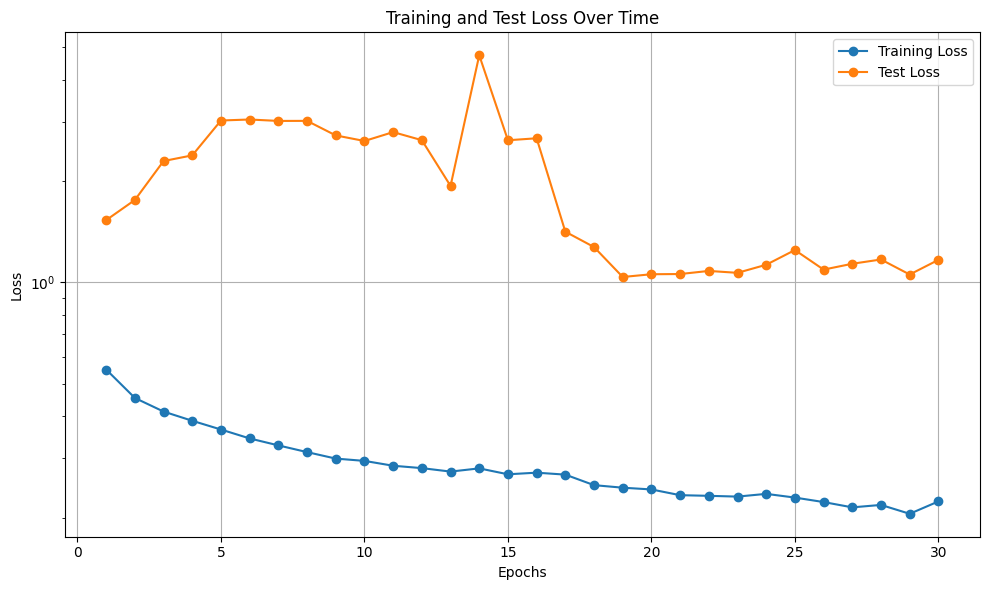

Inference Time: 0.1292 seconds
Optimal threshold: 0.043650, F1 score: 0.9717
Inference Time: 0.1292 seconds
Threshold used: 0.043649714

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.93      0.88    119460
     Anomaly       0.98      0.96      0.97    544288

    accuracy                           0.95    663748
   macro avg       0.91      0.94      0.93    663748
weighted avg       0.96      0.95      0.96    663748

Accuracy: 0.9541422347035321
F1 Score: 0.9716931123440647
Precision: 0.9838530465274822
Recall: 0.9598300899523782
ROC-AUC: 0.9776543205066675


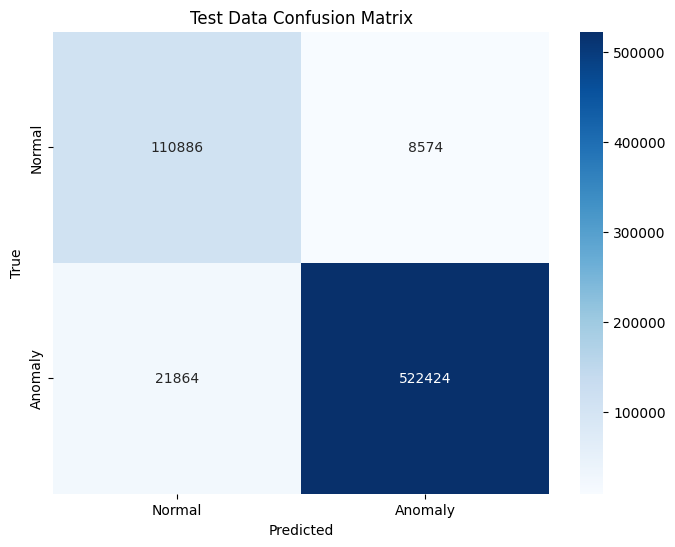


=== SUMMARY TABLE ===
Attack Type     Classifier      Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Binary          LSTM-AE         954.67          0.1292          278,738         663,748         35         0.9541     0.9839       0.9598     0.9717    


In [ ]:
# Add timing variables
total_train_time = 0
total_test_time = 0

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Lists to store loss values for plotting
train_losses = []
test_losses = []

# Get sample counts and feature info
n_train_samples = len(X_train)
n_test_samples = len(X_test)
n_features = X_train.shape[1]

print(f"Training samples (Normal only): {n_train_samples:,}")
print(f"Test samples (Normal + Attacks): {n_test_samples:,}")
print(f"Features: {n_features}")

# Training loop
n_epochs = 30
model.train()

# Start total training time
total_train_start = time.time()

for epoch in range(n_epochs):
    # Training phase
    model.train()
    epoch_loss = 0

    # Time each epoch
    epoch_start_time = time.time()

    for batch in train_loader:
        inputs = batch[0].to(device)

        if len(inputs.shape) == 2:
            inputs = inputs.unsqueeze(1)  

        outputs, _= model(inputs)  #
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_end_time = time.time()
    epoch_train_time = epoch_end_time - epoch_start_time

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)


# Evaluation phase - moved inside the epoch loop
    model.eval()
    with torch.no_grad():
        # Time the test/evaluation phase
        test_start_time = time.time()
        X_test_tensor_for_loss = X_test_tensor.to(device)

        if len(X_test_tensor_for_loss.shape) == 2:
            X_test_tensor_for_loss = X_test_tensor_for_loss.unsqueeze(1)  

        outputs, _ = model(X_test_tensor_for_loss)
        test_loss = criterion(outputs, X_test_tensor_for_loss).item()
        test_losses.append(test_loss)
    
        test_end_time = time.time()
        epoch_test_time = test_end_time - test_start_time

    scheduler.step(avg_train_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {test_loss:.4f}")

# End total training time
total_train_end = time.time()
total_train_time = total_train_end - total_train_start
print(f"\nTotal Training Time: {total_train_time:.2f} seconds")

# Plot the training and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Time')
plt.legend()
plt.grid(True)
plt.yscale('log') 
plt.tight_layout()
plt.show()


y_test_np = np.array(y_test)

model.eval()
with torch.no_grad():

    inference_start_time = time.time()
    X_test_tensor = X_test_tensor.to(device)

   
    if len(X_test_tensor.shape) == 2:
        X_test_tensor = X_test_tensor.unsqueeze(1)  

    reconstructions, _ = model(X_test_tensor)


    if len(X_test_tensor.shape) == 3:
       
        reconstruction_error = torch.mean((X_test_tensor - reconstructions) ** 2, dim=(1, 2)).cpu().numpy()
    else:
       
        reconstruction_error = torch.mean((X_test_tensor - reconstructions) ** 2, dim=1).cpu().numpy()

    inference_end_time = time.time()
    inference_time = inference_end_time - inference_start_time

print(f"Inference Time: {inference_time:.4f} seconds")


# Find optimal threshold
best_f1 = 0
best_threshold = 0

for percentile in range(0, 100):
    threshold = np.percentile(reconstruction_error, percentile)
    y_pred = (reconstruction_error > threshold).astype(int)
    f1 = f1_score(y_test_np, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal threshold: {best_threshold:.6f}, F1 score: {best_f1:.4f}")

# Apply the optimized threshold to test data
y_pred = (reconstruction_error > best_threshold).astype(int)


print(f"Inference Time: {inference_time:.4f} seconds")

# Compute metrics
print("Threshold used:", best_threshold)
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred, target_names=["Normal", "Anomaly"]))

accuracy = accuracy_score(y_test_np, y_pred)
print("Accuracy:", accuracy )
f1_score_ae = f1_score(y_test_np, y_pred)
print("F1 Score:", f1_score_ae)
precision = precision_score(y_test_np, y_pred)
print("Precision:",precision )
recall  =  recall_score(y_test_np, y_pred)
print("Recall:", recall)
print("ROC-AUC:", roc_auc_score(y_test_np, reconstruction_error))  # continuous error values

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Data Confusion Matrix")
plt.show()


print("\n=== SUMMARY TABLE ===")
print(f"{'Attack Type':<15} {'Classifier':<15} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 160)
print(f"{'Binary':<15} {'LSTM-AE':<15} {total_train_time:<15.2f} {inference_time:<15.4f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {accuracy:<10.4f} {precision:<12.4f} {recall:<10.4f} {f1_score_ae:<10.4f}")


In [ ]:
# Find indices of misclassifications
false_negatives = (y_test == 1) & (y_pred == 0)  # Missed attacks
false_positives = (y_test == 0) & (y_pred == 1)  # False alarms


fn_indices = test_indices[false_negatives]
fp_indices = test_indices[false_positives]

print("\n----- MISCLASSIFICATION ANALYSIS -----")
print(f"Number of false negatives (missed attacks): {np.sum(false_negatives)}")
print(f"Number of false positives (false alarms): {np.sum(false_positives)}")


print("\n----- TEST SET ANALYSIS -----")
test_df = df.iloc[test_indices].copy()
test_df['predicted'] = y_pred
test_df['actual'] = y_test


attack_types_in_test = test_df[test_df['Anomaly_Label'] == 'Attack']['Attack_Type'].unique()

print("\nDetection rate by attack type (sorted from highest to lowest):")


detection_rates_test_analysis = []
for attack_type in attack_types_in_test:
    attack_subset = test_df[(test_df['Attack_Type'] == attack_type) & 
                            (test_df['Anomaly_Label'] == 'Attack')]
    
    if len(attack_subset) > 0:
        total_attacks = len(attack_subset)
        detected_attacks = np.sum(attack_subset['predicted'] == 1)
        detection_rate = (detected_attacks / total_attacks) * 100
        detection_rates_test_analysis.append((attack_type, detection_rate, detected_attacks, total_attacks))


detection_rates_test_analysis.sort(key=lambda x: x[1], reverse=True)


for attack_type, detection_rate, detected_attacks, total_attacks in detection_rates_test_analysis:
    print(f"{attack_type}: {detection_rate:.2f}% detected ({detected_attacks}/{total_attacks})")


----- MISCLASSIFICATION ANALYSIS -----
Number of false negatives (missed attacks): 21864
Number of false positives (false alarms): 8574

----- TEST SET ANALYSIS -----

Detection rate by attack type (sorted from highest to lowest):
DoS_DoS SYN Flood: 99.89% detected (330142/330518)
DoS_DoS-UDP_Flood: 99.80% detected (105488/105701)
Mirai: 99.63% detected (3529/3542)
DDoS_DDoS ACK Fragmentation: 98.49% detected (48958/49710)
DoS_DoS-HTTP_Flood: 95.23% detected (23742/24931)
DDoS_DDoS-HTTP Flood: 77.56% detected (7948/10248)
DDoS_DDoS ICMP Flood: 27.63% detected (1131/4094)
DDoS_DDoS-ICMP_Fragmentation: 20.64% detected (1342/6503)
Benign&Bruteforce_BruteForce: 13.70% detected (10/73)
VulnerabilityScan: 1.49% detected (134/8968)


Training clustering methods...


  File "c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MELİSA\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
             

Evaluating clustering methods...

=== AUTOENCODER BASELINE ===
Attack Type     Classifier      Train Time (s)  Test Time (s)   Train Samples   Test Samples    Features   Accuracy   Precision    Recall     F1 Score  
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Binary          LSTM-AE         1717.25         0.1224          278,739         160,181         38         0.9776     0.9636       0.9476     0.9556    

=== COMBINED METHODS (AUTOENCODER + CLUSTERING) ===
Method             Train Time (s)  Test Time (s)   Combined F1  F1 Improve   Accuracy   Precision    Recall    
------------------------------------------------------------------------------------------------------------------------
K-Means            0.4841          0.0818          0.4363       -0.5193      0.3442     0.2791       0.9982    
DBSCAN             117.8963        0.2399          0.9558       0.0003  

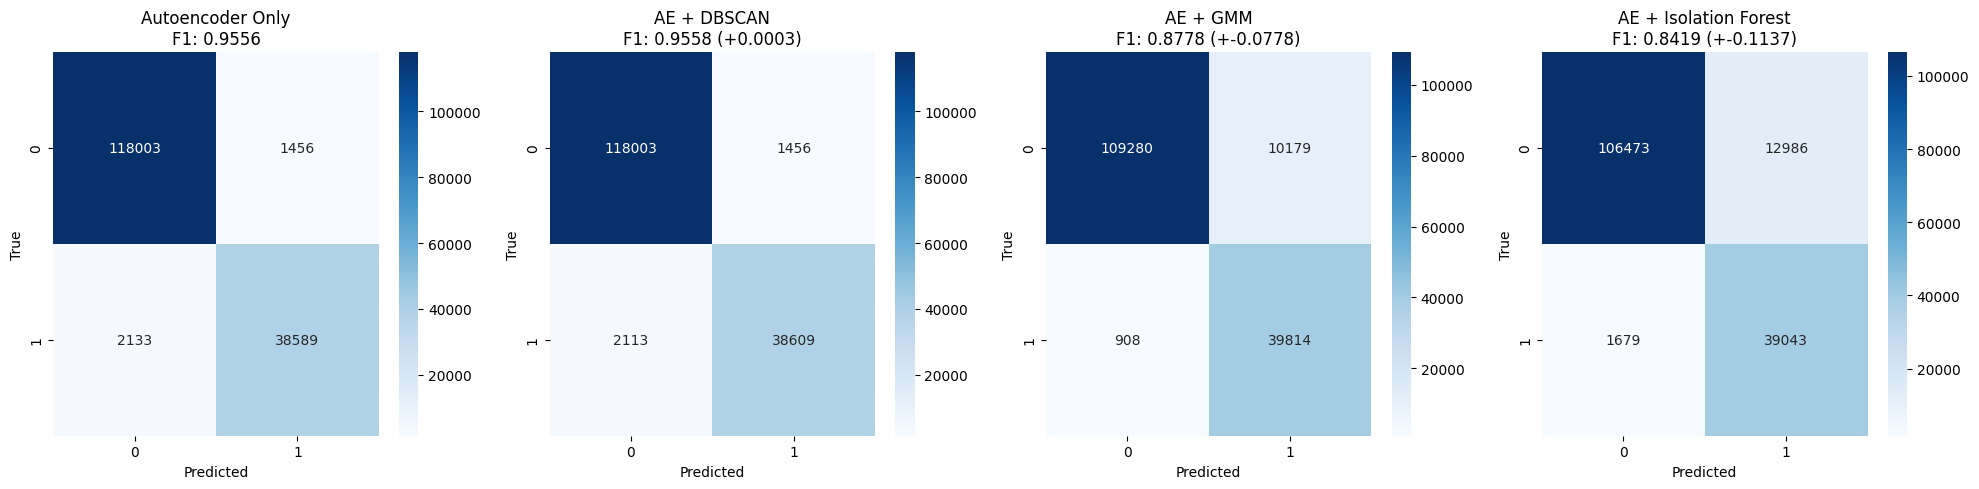


=== FINAL SUMMARY ===
Best performing method: DBSCAN
F1 improvement: 0.0003
Final combined F1 score: 0.9558
Samples analyzed for clustering: 120,136
Total clustering overhead: 132.5769 seconds
Best method efficiency: 0.000002 F1 improvement per second


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DATASET PREPARATION AND TIMING SETUP
# ============================================================================

# Extract data that autoencoder predicted as benign (normal)
benign_mask = (y_pred == 0)  # Autoencoder predicted as normal
X_benign_predicted = X_test[benign_mask]
y_benign_actual = y_test_np[benign_mask]  # Actual labels for these samples

try:
    n_train_samples = len(X_train)
    n_test_samples = len(X_test)
    n_features = X_test.shape[1]
except:
    n_train_samples = n_test_samples = n_features = 0

ae_accuracy = accuracy_score(y_test_np, y_pred)
ae_precision = precision_score(y_test_np, y_pred)
ae_recall = recall_score(y_test_np, y_pred)
ae_f1 = f1_score(y_test_np, y_pred)

# ============================================================================
# CLUSTERING PREPARATION
# ============================================================================

# Standardize the benign predicted data for clustering
scaler = StandardScaler()
X_benign_scaled = scaler.fit_transform(X_benign_predicted)
X_clustering = X_benign_scaled

clustering_results = {}
all_results = []

# ============================================================================
# CLUSTERING METHODS WITH TIMING
# ============================================================================

print("Training clustering methods...")

# 1. K-Means Clustering
start_time = time.time()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clustering)
clustering_results['K-Means'] = kmeans_labels
kmeans_time = time.time() - start_time

# 2. DBSCAN Clustering
start_time = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_clustering)
clustering_results['DBSCAN'] = dbscan_labels
dbscan_time = time.time() - start_time

# 3. Gaussian Mixture Model
start_time = time.time()
gmm = GaussianMixture(n_components=7, random_state=42)
gmm_labels = gmm.fit_predict(X_clustering)
clustering_results['GMM'] = gmm_labels
gmm_time = time.time() - start_time

# 4. Isolation Forest
start_time = time.time()
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso_labels = iso_forest.fit_predict(X_clustering)
clustering_results['Isolation Forest'] = iso_labels
iso_time = time.time() - start_time

# Store timing information
clustering_times = {
    'K-Means': kmeans_time,
    'DBSCAN': dbscan_time,
    'GMM': gmm_time,
    'Isolation Forest': iso_time
}

print("Evaluating clustering methods...")

# ============================================================================
# EVALUATION AND TESTING WITH TIMING
# ============================================================================

def evaluate_clustering_method(method_name, cluster_labels, y_true):
    """Evaluate a clustering method and return metrics"""
    start_time = time.time()
    
    if method_name == 'Isolation Forest':
        # Isolation Forest returns 1 for normal, -1 for anomaly
        y_pred_clustering = (cluster_labels == -1).astype(int)
    else:
        unique_clusters = np.unique(cluster_labels)
        cluster_anomaly_rates = {}
        
        for cluster in unique_clusters:
            cluster_mask = (cluster_labels == cluster)
            if np.sum(cluster_mask) > 0:
                anomaly_rate = np.mean(y_true[cluster_mask])
                cluster_anomaly_rates[cluster] = anomaly_rate
        
        if cluster_anomaly_rates:
            anomalous_cluster = max(cluster_anomaly_rates, key=cluster_anomaly_rates.get)
            y_pred_clustering = (cluster_labels == anomalous_cluster).astype(int)
        else:
            y_pred_clustering = np.zeros_like(cluster_labels)
    
    # Calculate clustering metrics
    clustering_accuracy = accuracy_score(y_true, y_pred_clustering)
    clustering_precision = precision_score(y_true, y_pred_clustering, zero_division=0)
    clustering_recall = recall_score(y_true, y_pred_clustering, zero_division=0)
    clustering_f1 = f1_score(y_true, y_pred_clustering, zero_division=0)
    
    # Calculate COMBINED performance (Autoencoder + Clustering)
    y_pred_combined = y_pred.copy()
    benign_indices = np.where(y_pred == 0)[0]
    y_pred_combined[benign_indices] = y_pred_clustering
    
    combined_accuracy = accuracy_score(y_test_np, y_pred_combined)
    combined_precision = precision_score(y_test_np, y_pred_combined, zero_division=0)
    combined_recall = recall_score(y_test_np, y_pred_combined, zero_division=0)
    combined_f1 = f1_score(y_test_np, y_pred_combined, zero_division=0)
    
    test_time = time.time() - start_time
    
    return {
        'method': method_name,
        'train_time': clustering_times[method_name],
        'test_time': test_time,
        'clustering_f1': clustering_f1,
        'combined_accuracy': combined_accuracy,
        'combined_precision': combined_precision,
        'combined_recall': combined_recall,
        'combined_f1': combined_f1,
        'f1_improvement': combined_f1 - ae_f1,
        'y_pred_combined': y_pred_combined
    }

# Evaluate all methods
for method_name, cluster_labels in clustering_results.items():
    result = evaluate_clustering_method(method_name, cluster_labels, y_benign_actual)
    all_results.append(result)

# ============================================================================
# SUMMARY TABLES
# ============================================================================

print("\n=== AUTOENCODER BASELINE ===")
print(f"{'Attack Type':<15} {'Classifier':<15} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Train Samples':<15} {'Test Samples':<15} {'Features':<10} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 160)

try:
    print(f"{'Binary':<15} {'LSTM-AE':<15} {total_train_time:<15.2f} {inference_time:<15.4f} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {ae_accuracy:<10.4f} {ae_precision:<12.4f} {ae_recall:<10.4f} {ae_f1:<10.4f}")
except NameError:
    print(f"{'Binary':<15} {'LSTM-AE':<15} {'N/A':<15} {'N/A':<15} {n_train_samples:<15,} {n_test_samples:<15,} {n_features:<10} {ae_accuracy:<10.4f} {ae_precision:<12.4f} {ae_recall:<10.4f} {ae_f1:<10.4f}")

# Combined methods summary
print("\n=== COMBINED METHODS (AUTOENCODER + CLUSTERING) ===")
print(f"{'Method':<18} {'Train Time (s)':<15} {'Test Time (s)':<15} {'Combined F1':<12} {'F1 Improve':<12} {'Accuracy':<10} {'Precision':<12} {'Recall':<10}")
print("-" * 120)

for result in all_results:
    print(f"{result['method']:<18} {result['train_time']:<15.4f} {result['test_time']:<15.4f} {result['combined_f1']:<12.4f} {result['f1_improvement']:<12.4f} {result['combined_accuracy']:<10.4f} {result['combined_precision']:<12.4f} {result['combined_recall']:<10.4f}")

# Performance ranking
print("\n=== PERFORMANCE RANKING (by F1 Improvement) ===")
sorted_results = sorted(all_results, key=lambda x: x['f1_improvement'], reverse=True)
print(f"{'Rank':<6} {'Method':<18} {'F1 Improvement':<15} {'Combined F1':<12} {'Total Time (s)':<15}")
print("-" * 75)
for i, result in enumerate(sorted_results, 1):
    total_time = result['train_time'] + result['test_time']
    print(f"{i:<6} {result['method']:<18} {result['f1_improvement']:<15.4f} {result['combined_f1']:<12.4f} {total_time:<15.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================


top_3_methods = sorted_results[:3]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot autoencoder baseline
cm_ae = confusion_matrix(y_test_np, y_pred)
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Autoencoder Only\nF1: {ae_f1:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Plot top 3 combined methods
for idx, result in enumerate(top_3_methods):
    cm_combined = confusion_matrix(y_test_np, result['y_pred_combined'])
    sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues', ax=axes[idx+1])
    axes[idx+1].set_title(f"AE + {result['method']}\nF1: {result['combined_f1']:.4f} (+{result['f1_improvement']:.4f})")
    axes[idx+1].set_xlabel('Predicted')
    axes[idx+1].set_ylabel('True')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n=== FINAL SUMMARY ===")
print(f"Best performing method: {sorted_results[0]['method']}")
print(f"F1 improvement: {sorted_results[0]['f1_improvement']:.4f}")
print(f"Final combined F1 score: {sorted_results[0]['combined_f1']:.4f}")
print(f"Samples analyzed for clustering: {len(X_benign_predicted):,}")
print(f"Total clustering overhead: {sum(clustering_times.values()):.4f} seconds")

# Calculate efficiency metrics
if sorted_results[0]['f1_improvement'] > 0:
    best_method = sorted_results[0]
    efficiency = best_method['f1_improvement'] / (best_method['train_time'] + best_method['test_time'])
    print(f"Best method efficiency: {efficiency:.6f} F1 improvement per second")
else:
    print("No method showed F1 improvement over autoencoder baseline")